In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("msambare/fer2013")

print(dataset_path)

Using Colab cache for faster access to the 'fer2013' dataset.
/kaggle/input/fer2013


In [3]:
print(os.listdir(dataset_path))

['test', 'train']


In [4]:
print(os.listdir(dataset_path + "/train"))

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [5]:
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

In [6]:
IMG_SIZE = (160,160)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    color_mode="rgb"
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


In [7]:
class_names = train_ds.class_names

print(class_names)
print("Number of classes:", len(class_names))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


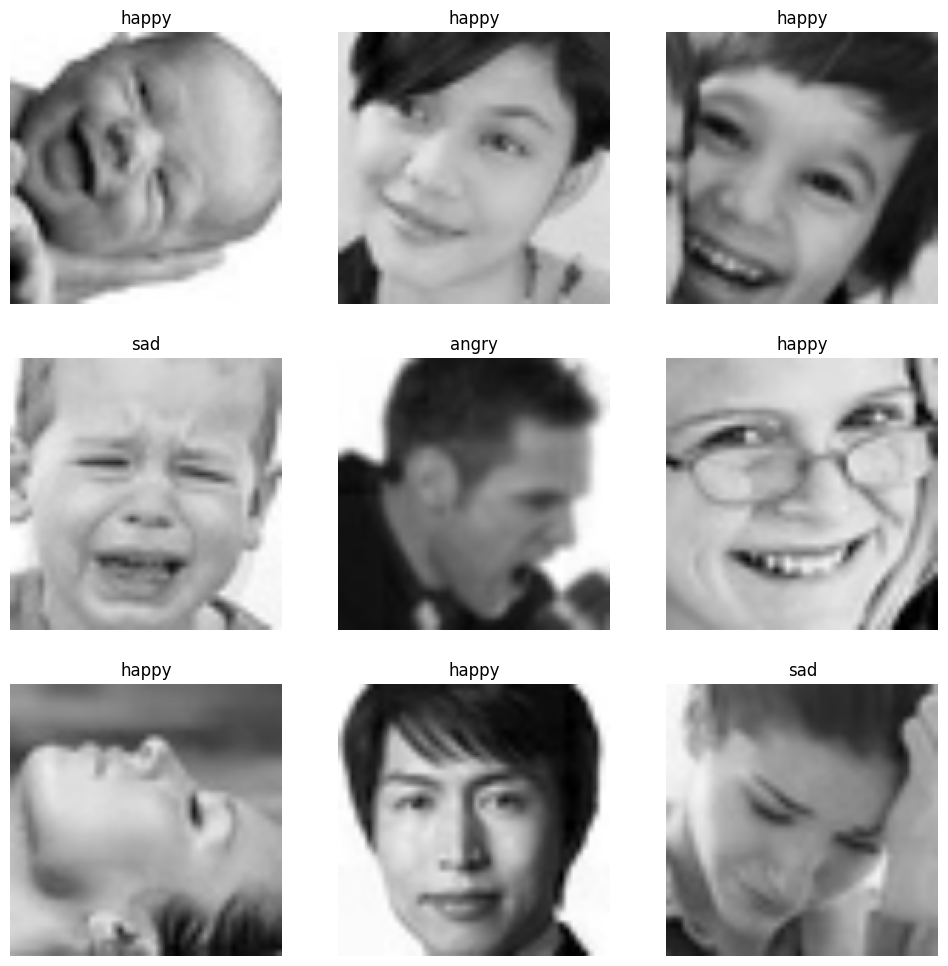

In [8]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [9]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [12]:
inputs = tf.keras.Input(shape=(160,160,3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(7, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    save_best_only=True
)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 91s 51ms/step - accuracy: 0.3532 - loss: 1.7469 - val_accuracy: 0.4362 - val_loss: 1.5013 - learning_rate: 0.0010
Epoch 2/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.4110 - loss: 1.5570 - val_accuracy: 0.4473 - val_loss: 1.4703 - learning_rate: 0.0010
Epoch 3/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.4133 - loss: 1.5453 - val_accuracy: 0.4313 - val_loss: 1.5311 - learning_rate: 0.0010
Epoch 4/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.4209 - loss: 1.5289 - val_accuracy: 0.4376 - val_loss: 1.4749 - learning_rate: 0.0010
Epoch 5/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 43s 40ms/step - accuracy: 0.4419 - loss: 1.4669 - val_accuracy: 0.4600 - val_loss: 1.4188 - learning_rate: 2.0000e-04


In [17]:
base_model.trainable = True

# Freeze the first 100 layers
for layer in base_model.layers[:100]:
    layer.trainable = False

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,

    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 78s 67ms/step - accuracy: 0.3621 - loss: 1.7479 - val_accuracy: 0.4597 - val_loss: 1.4553 - learning_rate: 1.0000e-05
Epoch 2/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.4315 - loss: 1.4931 - val_accuracy: 0.4780 - val_loss: 1.4246 - learning_rate: 1.0000e-05
Epoch 3/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 59s 64ms/step - accuracy: 0.4593 - loss: 1.4190 - val_accuracy: 0.4867 - val_loss: 1.3727 - learning_rate: 2.0000e-06
Epoch 4/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.4708 - loss: 1.4043 - val_accuracy: 0.4931 - val_loss: 1.3521 - learning_rate: 2.0000e-06
Epoch 5/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 59s 64ms/step - accuracy: 0.4727 - loss: 1.3911 - val_accuracy: 0.4943 - val_loss: 1.3384 - learning_rate: 2.0000e-06


In [23]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - accuracy: 0.5011 - loss: 1.3339
Test Accuracy: 0.5011
Test Loss: 1.3339


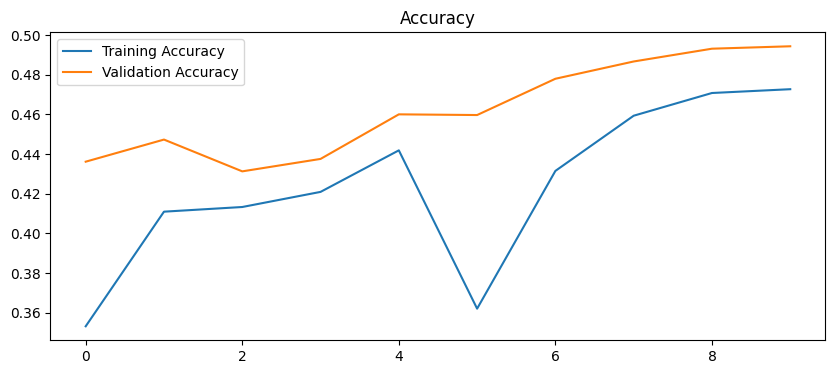

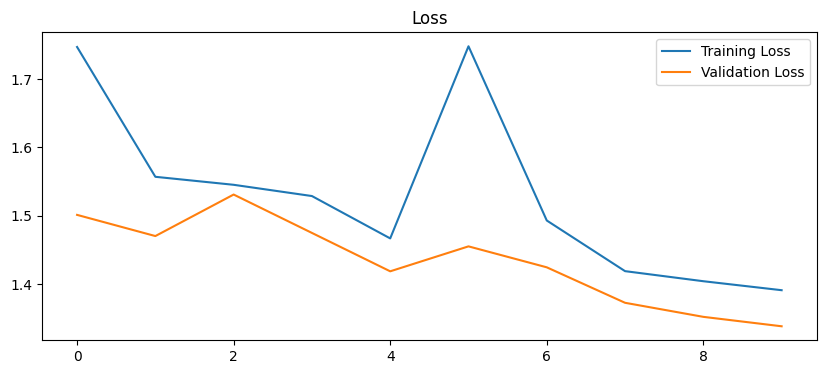

In [24]:
import matplotlib.pyplot as plt

acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

plt.figure(figsize=(10,4))
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")
plt.savefig("accuracy_plot.png")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.savefig("loss_plot.png")
plt.show()

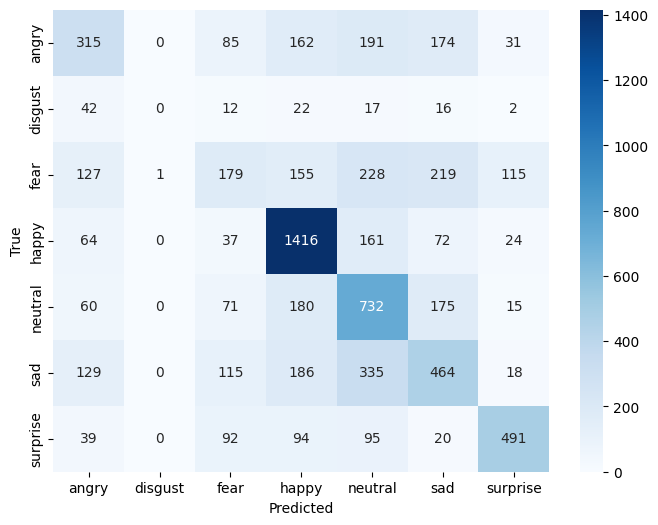

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png")
plt.show()

In [26]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.41      0.33      0.36       958
     disgust       0.00      0.00      0.00       111
        fear       0.30      0.17      0.22      1024
       happy       0.64      0.80      0.71      1774
     neutral       0.42      0.59      0.49      1233
         sad       0.41      0.37      0.39      1247
    surprise       0.71      0.59      0.64       831

    accuracy                           0.50      7178
   macro avg       0.41      0.41      0.40      7178
weighted avg       0.48      0.50      0.48      7178



In [27]:
model.save("emotion_recognition.keras")

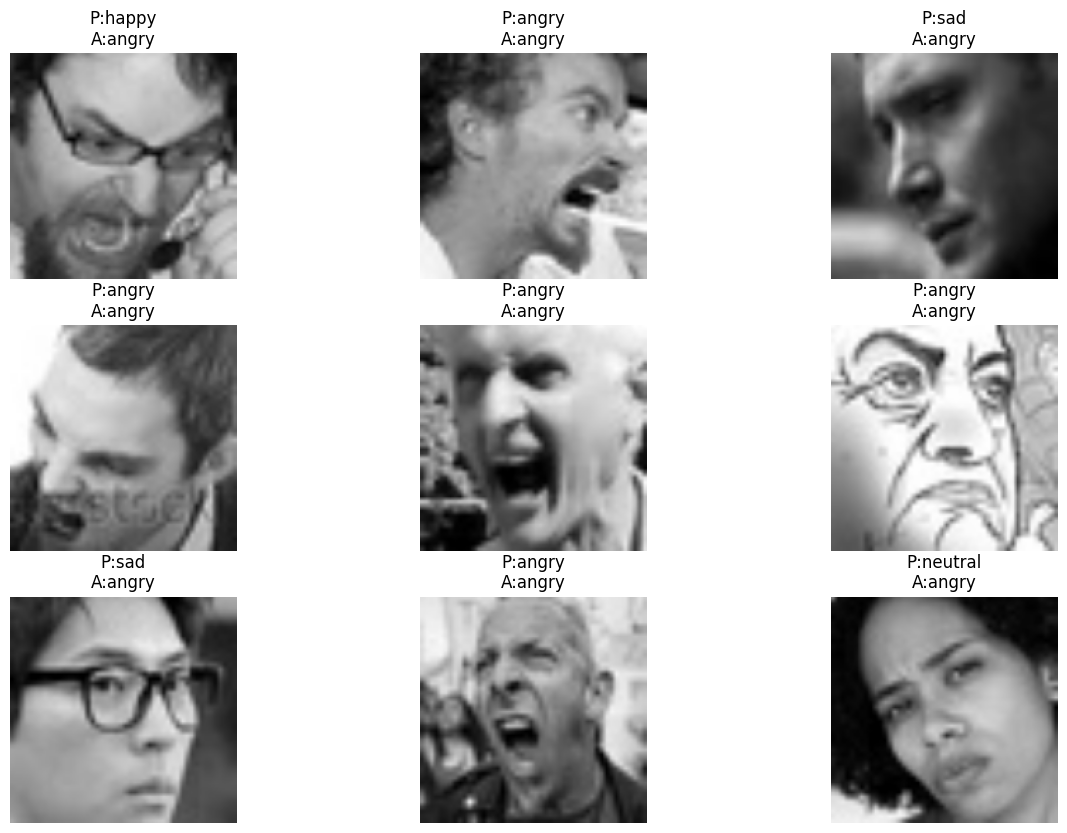

In [28]:
plt.figure(figsize=(15,10))

for images, labels in test_ds.take(1):

    predictions = model.predict(images, verbose=0)

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        pred = class_names[np.argmax(predictions[i])]

        actual = class_names[labels[i]]

        plt.title(f"P:{pred}\nA:{actual}")

        plt.axis("off")

plt.show()